### Metrics Evaluation on AI Vision Extract

In [ ]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility 
np.random.seed(42)

### Create a simple 2x2 ground truth and prediction

In [ ]:
# GT: [[1,0],[0,1]]  Pred: [[1,1],[0,1]] 

ground_truth = np.array([[1, 0], [0, 1]])
prediction = np.array([[1, 1], [0, 1]])

print("Ground Truth:\n", ground_truth)
print("Prediction:\n", prediction)
print("\nTrue Positives (TP):", np.sum((ground_truth == 1) & (prediction == 1)))
print("False Positives (FP):", np.sum((ground_truth == 0) & (prediction == 1)))
print("False Negatives (FN):", np.sum((ground_truth == 1) & (prediction == 0)))
print("True Negatives (TN):", np.sum((ground_truth == 0) & (prediction == 0)))

Ground Truth:
 [[1 0]
 [0 1]]
Prediction:
 [[1 1]
 [0 1]]

True Positives (TP): 2
False Positives (FP): 1
False Negatives (FN): 0
True Negatives (TN): 1


#### 1. Pixel Accuracy
- It counts how many pixels your model got right, regardless of what they represent.
- Pixel Accuracy = ```(Number of Correctly Classified Pixels)``` / ```(Total Number of Pixels)```

✅ Pixel Accuracy: 0.750 or 75.0%


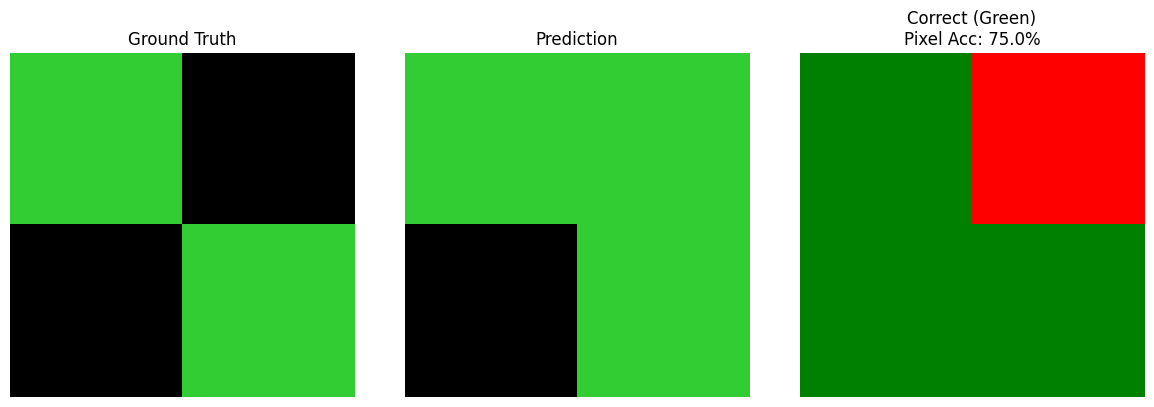

📊 Pixel Accuracy counts:
Correct pixels: 2/4 = 50%


In [ ]:
def pixel_accuracy(gt, pred):
  return np.sum(gt == pred) / gt.size


gt = ground_truth
pred = prediction

# Calculates
px_acc = pixel_accuracy(gt, pred)
print(f"✅ Pixel Accuracy: {px_acc:.3f} or {px_acc*100:.1f}%")

# Visual explanation
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cmap = ListedColormap(['black', 'limegreen'])

axes[0].imshow(ground_truth, cmap=cmap, vmin=0, vmax=1)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(prediction, cmap=cmap, vmin=0, vmax=1)
axes[1].set_title('Prediction')
axes[1].axis('off')

diff = (gt == pred).astype(int)
axes[2].imshow(diff, cmap=ListedColormap(['red', 'green']), vmin=0, vmax=1)
axes[2].set_title(f'Correct (Green)\nPixel Acc: {px_acc:.1%}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("📊 Pixel Accuracy counts:\nCorrect pixels: 2/4 = 50%")

#### 2. Precision
- It measures how many of the pixels predicted as a certain class are actually that class.
- Precision = ```True Positives``` / ```(True Positives + False Positives)```

✅ Precision: 0.667 or 66.7%


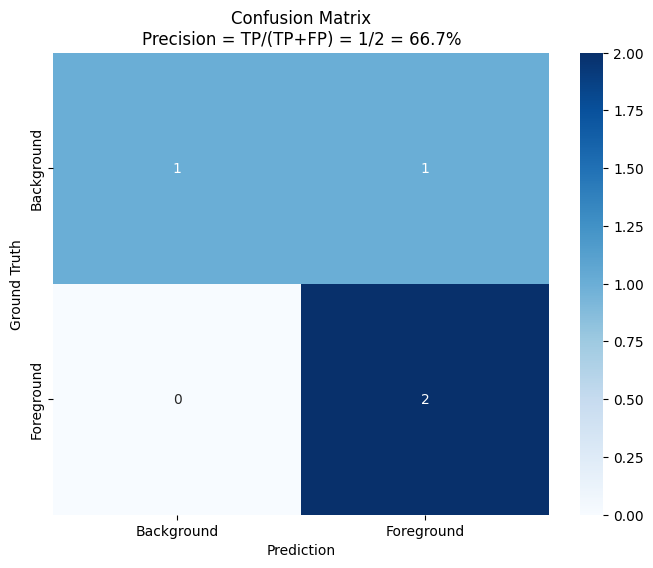

📊 Precision explanation:
Of all predicted foreground pixels (2), 1 was correct = 50%


In [ ]:
def precision(gt, pred):
    """Precision = TP / (TP + FP)"""
    tp = np.sum((gt == 1) & (pred == 1))
    fp = np.sum((gt == 0) & (pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0
prec = precision(ground_truth, prediction)
print(f"✅ Precision: {prec:.3f} or {prec*100:.1f}%")

# Confusion Matrix Visualization
cm = confusion_matrix(gt.flatten(), pred.flatten())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Foreground'],
            yticklabels=['Background', 'Foreground'])
plt.title(f'Confusion Matrix\nPrecision = TP/(TP+FP) = 1/2 = {prec:.1%}')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()

print("📊 Precision explanation:\nOf all predicted foreground pixels (2), 1 was correct = 50%")

#### 3. Recall
- It measures how many of the actual pixels of a certain class were correctly predicted.
- Recall = ```True Positives``` / ```(True Positives + False Negatives)```

✅ Recall: 1.000 or 100.0%


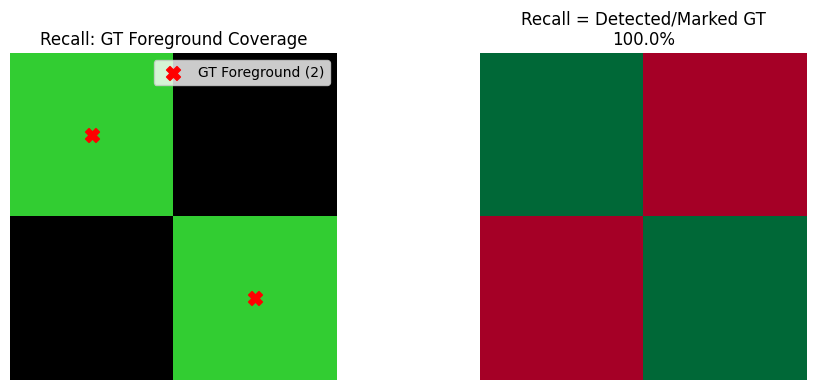

In [ ]:
def recall(gt, pred):
    """Recall = TP / (TP + FN)"""
    tp = np.sum((gt == 1) & (pred == 1))
    fn = np.sum((gt == 1) & (pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0

rec = recall(ground_truth, prediction)
print(f"✅ Recall: {rec:.3f} or {rec*100:.1f}%")

# Recall visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# GT foreground pixels
gt_fg_mask = ground_truth == 1
ax1.imshow(ground_truth, cmap=cmap, vmin=0, vmax=1)
ax1.scatter([0,1], [0,1], c='red', s=100, marker='X', label='GT Foreground (2)')
ax1.set_title('Recall: GT Foreground Coverage')
ax1.legend()
ax1.axis('off')

# Detected vs GT
detected_correct = ((ground_truth == 1) & (prediction == 1)).astype(int)
ax2.imshow(ground_truth * 2 + detected_correct, cmap='RdYlGn', vmin=0, vmax=2)
ax2.set_title(f'Recall = Detected/Marked GT\n{rec:.1%}')
ax2.axis('off')

plt.tight_layout()
plt.show()


#### 4. Dice Coefficient
- It is a measure of overlap between two samples. It ranges from 0 (no overlap) to 1 (perfect overlap).
- Dice Coefficient = ```(2 * |A ∩ B|)``` / ```(|A| + |B|)```
    - where A = set of predicted pixels, B = set of ground truth pixels
- It emphasizes the importance of correctly predicted pixels by giving them double weight in the numerator. so it is particularly useful in scenarios with class imbalance.

✅ Dice Coefficient: 0.800 or 80.0%


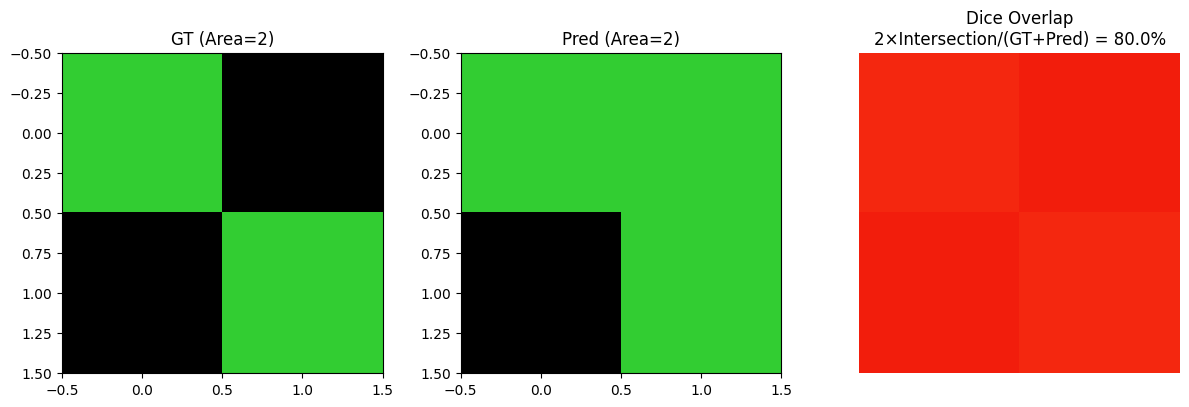

In [ ]:
def dice_coefficient(gt, pred):
    """Dice = 2 * TP / (2 * TP + FP + FN)"""
    tp = np.sum((gt == 1) & (pred == 1))
    fp = np.sum((gt == 0) & (pred == 1))
    fn = np.sum((gt == 1) & (pred == 0))
    return 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

dice = dice_coefficient(ground_truth, prediction)
print(f"✅ Dice Coefficient: {dice:.3f} or {dice*100:.1f}%")

# Dice overlap visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
intersection = (ground_truth == 1) & (prediction == 1)

axes[0].imshow(ground_truth, cmap=cmap, vmin=0, vmax=1)
axes[0].set_title('GT (Area=2)')

axes[1].imshow(prediction, cmap=cmap, vmin=0, vmax=1)
axes[1].set_title('Pred (Area=2)')

axes[2].imshow(ground_truth, cmap=cmap, alpha=0.5)
axes[2].imshow(prediction, cmap=ListedColormap(['orange']), alpha=0.5)
axes[2].imshow(intersection, cmap=ListedColormap(['red']), alpha=0.8)
axes[2].set_title(f'Dice Overlap\n2×Intersection/(GT+Pred) = {dice:.1%}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#### 5. Intersection over Union (IoU)
- It measures the overlap between the predicted segmentation and the ground truth segmentation.
- IoU = ```|A ∩ B|``` / ```|A ∪ B|```
    - where A = set of predicted pixels, B = set of ground truth pixels
- It expresses how well the predicted segmentation matches the ground truth by calculating the ratio of the intersection to the union of the two sets. So it is widely used in segmentation tasks.

✅ IoU: 0.667 or 66.7%


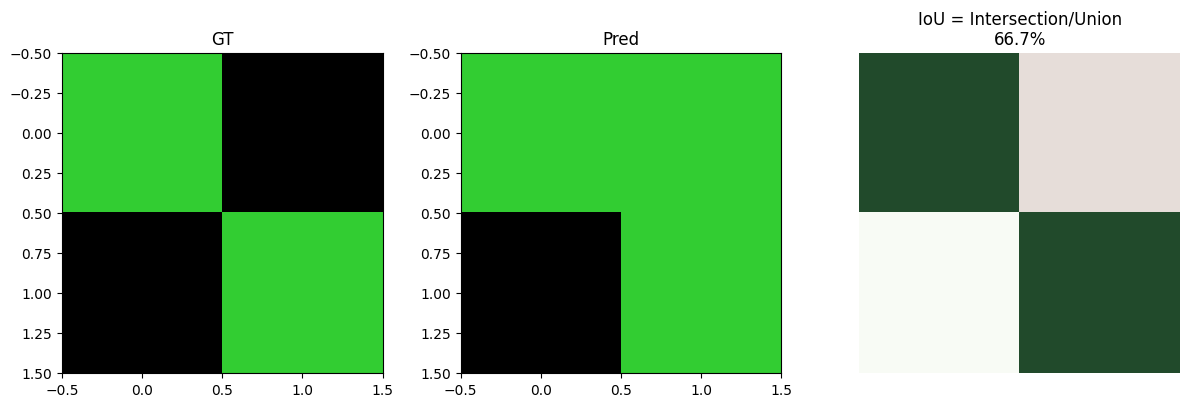

In [ ]:
def iou(gt, pred):
    """IoU = TP / (TP + FP + FN)"""
    tp = np.sum((gt == 1) & (pred == 1))
    fp = np.sum((gt == 0) & (pred == 1))
    fn = np.sum((gt == 1) & (pred == 0))
    return tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0

iou_score = iou(ground_truth, prediction)
print(f"✅ IoU: {iou_score:.3f} or {iou_score*100:.1f}%")


# IoU visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

union = (gt == 1) | (pred == 1)
intersection = (gt == 1) & (pred == 1)

axes[0].imshow(gt, cmap=cmap)
axes[0].set_title('GT')

axes[1].imshow(pred, cmap=cmap)
axes[1].set_title('Pred')

axes[2].imshow(union.astype(int), cmap='Reds', alpha=0.6)
axes[2].imshow(intersection.astype(int)*2, cmap='Greens', alpha=0.8)
axes[2].set_title(f'IoU = Intersection/Union\n{iou_score:.1%}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#### 6. Boundary F1 Score
- It measures the accuracy of the predicted boundaries of segmented objects compared to the ground truth boundaries.
- Boundary F1 Score = ```2 * (Precision * Recall) / (Precision + Recall)```
- It focuses on the edges of objects, making it useful for evaluating segmentation models where boundary accuracy is critical.

✅ Boundary F1: 0.800


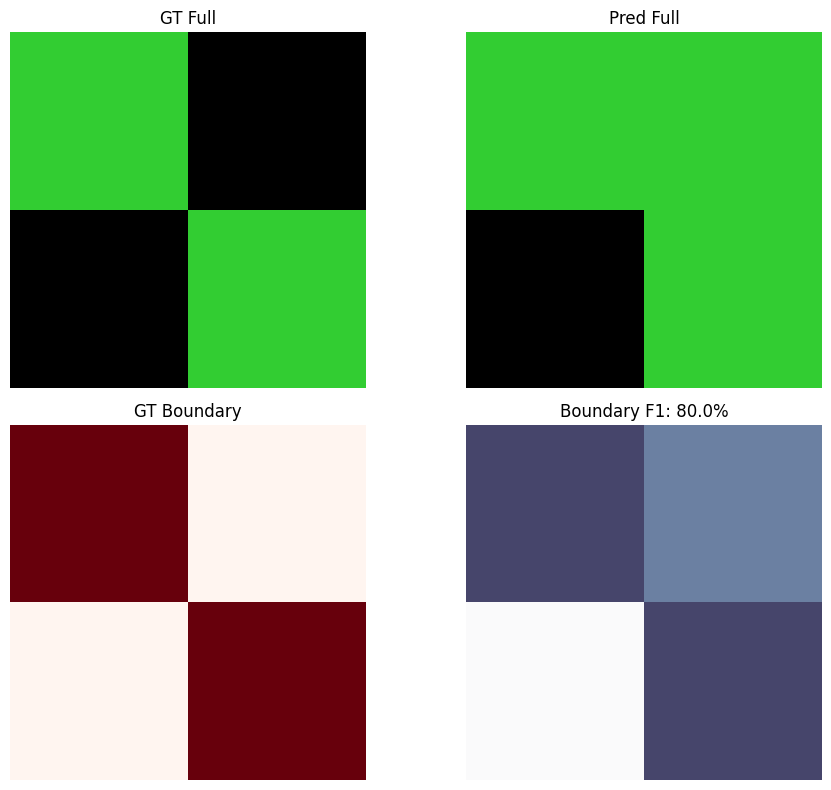

In [ ]:
def get_boundary(mask, thickness=1):
    """Extract boundary pixels"""
    from scipy import ndimage
    eroded = ndimage.binary_erosion(mask, structure=np.ones((3,3)))
    return mask ^ eroded

def boundary_f1(gt, pred, dist_thresh=1):
    """Simplified Boundary F1"""
    gt_boundary = get_boundary(gt)
    pred_boundary = get_boundary(pred)

    tp = np.sum((gt_boundary == 1) & (pred_boundary == 1))
    fp = np.sum((gt_boundary == 0) & (pred_boundary == 1))
    fn = np.sum((gt_boundary == 1) & (pred_boundary == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return f1

# For our simple example
bf1 = boundary_f1(ground_truth, prediction)
print(f"✅ Boundary F1: {bf1:.3f}")

# Boundary visualization
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].imshow(ground_truth, cmap=cmap)
axes[0,0].set_title('GT Full')

axes[0,1].imshow(prediction, cmap=cmap)
axes[0,1].set_title('Pred Full')

gt_bdry = get_boundary(ground_truth)
pred_bdry = get_boundary(prediction)
axes[1,0].imshow(gt_bdry, cmap='Reds')
axes[1,0].set_title('GT Boundary')

axes[1,1].imshow(gt_bdry, cmap='Reds', alpha=0.6)
axes[1,1].imshow(pred_bdry, cmap='Blues', alpha=0.6)
axes[1,1].set_title(f'Boundary F1: {bf1:.1%}')
for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()



#### Ideal, Good, and Acceptable Targets for Segmentation Metrics

| Metric            | Ideal Target | Good Target | Acceptable | Notes                                                                              |
| ----------------- | ------------ | ----------- | ---------- | ---------------------------------------------------------------------------------- |
| Pixel Accuracy    | >0.95        | 0.90-0.95   | >0.85      | Biased by background pixels; less reliable for imbalanced classes geeksforgeeks+1​ |
| Precision         | >0.95        | 0.90-0.95   | >0.85      | Minimizes false positives (over-segmentation) geeksforgeeks​                       |
| Recall            | >0.95        | 0.90-0.95   | >0.85      | Ensures all true regions captured (avoids misses) geeksforgeeks​                   |
| Dice Coefficient  | >0.90        | 0.85-0.90   | >0.80      | Gold standard for overlap; 1.0 = perfect match geeksforgeeks+1​                    |
| IoU (Jaccard)     | >0.85        | 0.80-0.85   | >0.75      | Strict overlap measure; Dice/2 ≈ IoU for high values geeksforgeeks+1​              |
| Boundary F1 Score | >0.85        | 0.80-0.85   | >0.75      | Edge quality focus; sensitive to boundary errors encord​                           |